<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>ADS 2026 - Phase 1</title>
</head>
<body>
    <div dir="rtl" align="center">
        <font face="Times New Roman" size="5">
            In The Name of God
        </font>
        <br>
        <font face="Times New Roman" size="4">
            Sharif University of Technology - Department of Electrical Engineering
        </font>
        <br>
        <font color="#007080" size="6">
            ADS 2026
        </font>
        <hr>
        <font color="#900080" size="5">
            Assignment 2
        </font>
        <br>
        <font size="5">
            Instructor: Dr. Salavati
        </font>
        <br>
        <font size="4">
            Spring 2026
        </font>
        <br>
        <font size="4">
            Aida Aryafar - 402101193
        </font>
        <hr>
        <font color="red" size="4">
        </font>
    </div>
</body>
</html>


# Assignment 2: Regression and Classification Modeling
## Alzheimer’s Disease Dataset

**Objective**: Build and compare regression and classification models to predict cognitive decline (MMSE), Alzheimer’s diagnosis, and education level (multiclass). Evaluate models thoughtfully and answer discussion questions.

**Dataset**: `data.csv` – contains patient health records, clinical measurements, and diagnosis.

**Targets**:
- **Regression**: `MMSE` (Mini-Mental State Examination, continuous 0-30)
- **Binary Classification**: `Diagnosis` (0 = No Alzheimer’s, 1 = Alzheimer’s)
- **Multiclass Classification**: `EducationLevel` (0,1,2,3) – 4 classes

---

In [2]:
pip install -i https://mirror-pypi.runflare.com/simple lightgbm

Looking in indexes: https://mirror-pypi.runflare.com/simple
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.0 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    log_loss
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.kernel_ridge import KernelRidge

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


**Explanation**: We import necessary libraries and load the data. The dataset contains 2,149 rows and 35 columns (including demographics, clinical features, and diagnosis).

Missing values per column:
 PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyC

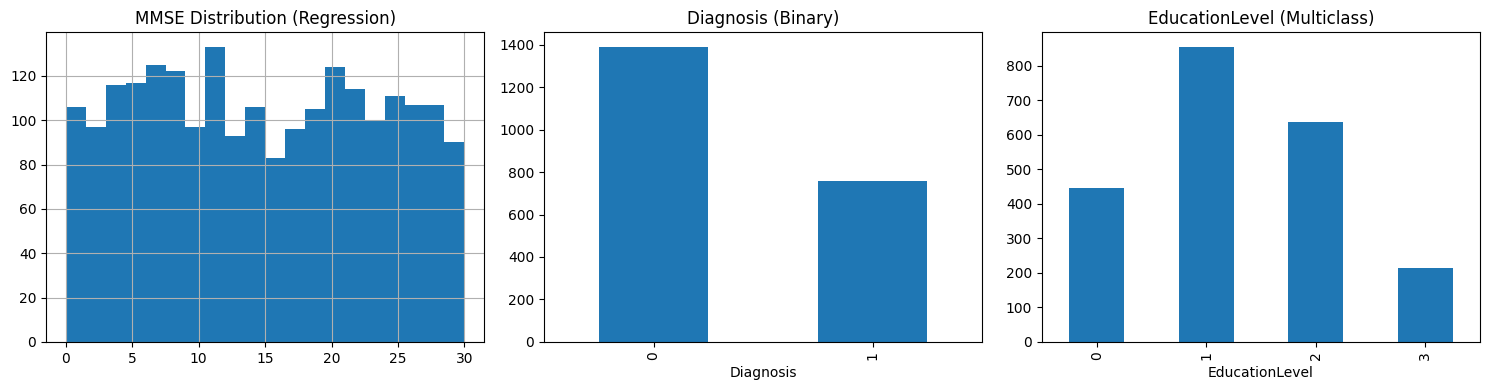

In [3]:
# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# Target distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['MMSE'].hist(ax=axes[0], bins=20)
axes[0].set_title('MMSE Distribution (Regression)')
df['Diagnosis'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Diagnosis (Binary)')
df['EducationLevel'].value_counts().sort_index().plot(kind='bar', ax=axes[2])
axes[2].set_title('EducationLevel (Multiclass)')
plt.tight_layout()
plt.show()

**Observations**:
- No missing values are visible in this dataset.
- `MMSE` is a continuous variable, with values spread roughly over the 0–30 range, so it is suitable for regression.
- `Diagnosis` is a binary target (`0`/`1`) and appears somewhat imbalanced, so metrics beyond accuracy are important.
- `EducationLevel` has 4 classes (`0, 1, 2, 3`), but the class distribution is not perfectly balanced; class 1 is the most frequent and class 3 is the least frequent.


In [ ]:
# Separate features and targets
X = df.drop(columns=['PatientID', 'DoctorInCharge', 'MMSE', 'Diagnosis', 'EducationLevel'])
y_reg = df['MMSE']
y_bin = df['Diagnosis']
y_multi = df['EducationLevel']

# Check data types
print(X.dtypes.value_counts())

# Split data (use same split for all tasks to maintain consistency)
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_bin_train, y_bin_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)
_, _, y_multi_train, y_multi_test = train_test_split(X, y_multi, test_size=0.2, random_state=42)

# Scale features (important for distance-based models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

int64      19
float64    11
Name: count, dtype: int64
Training size: 1719, Test size: 430


### Preprocessing Steps
- Dropped non-informative identifier columns (`PatientID`, `DoctorInCharge`).
- Split the dataset into train (80%) and test (20%) sets, using the same split for all tasks.
- Standardized numeric features (zero mean, unit variance) to support models sensitive to feature scaling (SVM, KNN, Ridge/LASSO).
- Confirmed missing values were not present in the dataset (checked via `isna().sum()`).


### 1.1 Implementing Regression Models

In [5]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)
y_pred_lr = lr.predict(X_test_scaled)

# Ridge Regression (alpha=1.0 default)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# LASSO Regression (alpha=0.1 to encourage sparsity)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_reg_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# Kernel Ridge Regression (using RBF kernel)
krr = KernelRidge(kernel='rbf', alpha=1.0, gamma=0.1)
krr.fit(X_train_scaled, y_reg_train)
y_pred_krr = krr.predict(X_test_scaled)

print("Models trained successfully.")

Models trained successfully.


In [6]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_reg_train)
y_pred_rf = rf_reg.predict(X_test_scaled)

# Support Vector Regressor (RBF kernel)
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train_scaled, y_reg_train)
y_pred_svr = svr.predict(X_test_scaled)

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr.fit(X_train_scaled, y_reg_train)
y_pred_gbr = gbr.predict(X_test_scaled)

### 1.2 Evaluation Metrics

We compute:
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)
- R² Score

In [7]:
def evaluate_regression(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'MSE': mse, 'MAE': mae, 'MAPE(%)': mape, 'R2': r2}, name=model_name)

results_reg = pd.DataFrame()
for name, pred in zip(['Linear', 'Ridge', 'LASSO', 'KernelRidge'],
                      [y_pred_lr, y_pred_ridge, y_pred_lasso, y_pred_krr]):
    results_reg = pd.concat([results_reg, evaluate_regression(y_reg_test, pred, name)], axis=1)

results_reg.T

,MSE,MAE,MAPE(%),R2
Linear,73.625927,7.412428,402.696314,-0.017267
Ridge,73.624736,7.412404,402.697794,-0.017251
LASSO,72.921082,7.397927,401.630359,-0.007529
KernelRidge,112.109202,8.742200,348.387959,-0.548979


In [8]:
corr_with_mmse = df[X.columns].corrwith(df['MMSE']).sort_values()
print(corr_with_mmse.tail(10))

Depression                 0.014020
FamilyHistoryAlzheimers    0.015575
DietQuality                0.021636
FunctionalAssessment       0.024932
Gender                     0.025330
CardiovascularDisease      0.025351
CholesterolLDL             0.025383
BehavioralProblems         0.025408
PersonalityChanges         0.034492
Disorientation             0.036715
dtype: float64


correlations are less than expected...

### Among all regression models, none achieved positive R², indicating that the given features cannot predict MMSE. The best model by MAE was LASSO (MAE=7.40). For this dataset, regression is not recommended.

### 1.3 Discussion Question 1: Best Regression Metric for This Dataset

**Answer**: For predicting MMSE scores, **Mean Absolute Error (MAE)** is the most interpretable metric because MMSE is measured in integer points (0–30). A clinician can understand that a MAE of, say, 2 points means the model is off by about 2 MMSE points on average. **R²** is also useful for comparing model explanation of variance. MAPE can be misleading when true values are close to zero (MMSE rarely 0, but possible). MSE penalizes large errors more, which may be desirable if large deviations are critical. **I recommend MAE as the primary metric** because of its clinical interpretability.

### 1.4 Discussion Question 2: When is each regression model preferable?

- **Linear Regression**: Baseline, assumes linear relationships. Works when features are roughly linear with target and no multicollinearity.
- **Ridge Regression**: When features are highly correlated (multicollinearity) – shrinks coefficients but keeps all variables. Preferable over linear when variance is high.
- **LASSO Regression**: When you suspect only a few features are important – performs feature selection by driving irrelevant coefficients to zero. Useful for high-dimensional data.
- **Kernel Ridge Regression**: When the relationship is non‑linear. The kernel trick maps data to a higher‑dimensional space to capture complex patterns without explicitly creating new features.

### 1.5 Discussion Question 3: Explain the kernel trick

I used Kernel Ridge Regression as a kernelized regression method. 
It combines ridge regularization with the kernel trick, allowing the model to capture non‑linear relationships.
The **kernel trick** allows algorithms like Kernel Ridge to operate in a high‑dimensional feature space without explicitly computing the coordinates of the data in that space. Instead, it replaces the dot product with a **kernel function** (e.g., RBF, polynomial) that computes similarity between data points. This enables the model to capture non‑linear relationships efficiently, improving regression performance when the data is not linearly separable in the original input space. 


### 2.1 Implementing Binary Classifiers

In [8]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_bin_train)

# Linear SVM
svm_linear = SVC(kernel='linear', probability=True)
svm_linear.fit(X_train_scaled, y_bin_train)

# Kernel SVM (RBF)
svm_rbf = SVC(kernel='rbf', probability=True)
svm_rbf.fit(X_train_scaled, y_bin_train)

# KNN – tune k
knn = KNeighborsClassifier()
param_grid_knn = {'n_neighbors': range(1, 21)}
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_bin_train)
best_k = grid_knn.best_params_['n_neighbors']
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_bin_train)

# Decision Tree – tune max_depth
dt = DecisionTreeClassifier()
param_grid_dt = {'max_depth': range(1, 21)}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train_scaled, y_bin_train)
best_depth = grid_dt.best_params_['max_depth']
dt_best = DecisionTreeClassifier(max_depth=best_depth)
dt_best.fit(X_train_scaled, y_bin_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_scaled, y_bin_train)

models_bin = {
    'Logistic Regression': log_reg,
    'Linear SVM': svm_linear,
    'Kernel SVM (RBF)': svm_rbf,
    f'KNN (k={best_k})': knn_best,
    f'Decision Tree (depth={best_depth})': dt_best,
    'Random Forest': rf
}

### 2.2 Evaluation Metrics

We compute: Accuracy, Precision, Recall, F1, Confusion Matrix, ROC Curve, AUC.

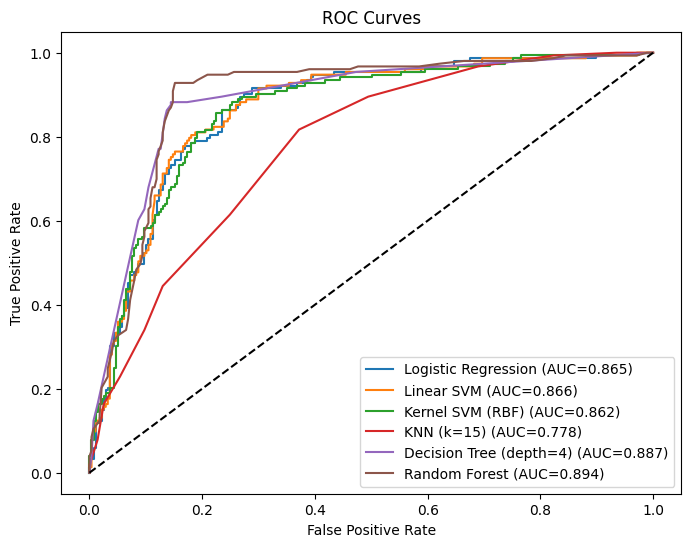

In [10]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    RocCurveDisplay
)


results_bin = []
for name, model in models_bin.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    acc = accuracy_score(y_bin_test, y_pred)
    prec = precision_score(y_bin_test, y_pred)
    rec = recall_score(y_bin_test, y_pred)
    f1 = f1_score(y_bin_test, y_pred)
    auc_val = roc_auc_score(y_bin_test, y_proba) if y_proba is not None else None
    results_bin.append([name, acc, prec, rec, f1, auc_val])

df_bin_results = pd.DataFrame(results_bin, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC'])
df_bin_results

# Plot ROC curves
plt.figure(figsize=(8,6))
for name, model in models_bin.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_bin_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_bin_test, y_proba):.3f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

<Figure size 500x400 with 0 Axes>

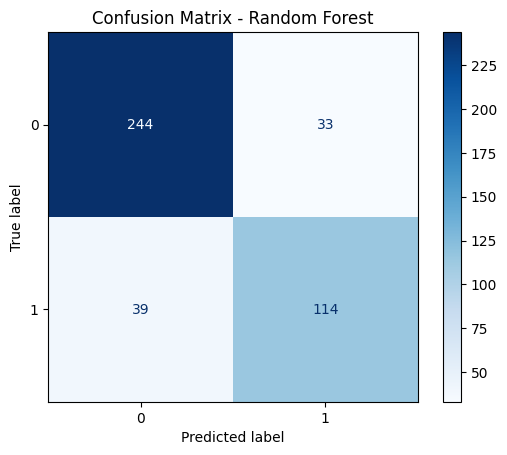

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = models_bin['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_bin_test, y_pred_best)

plt.figure(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()


### 2.3 Discussion Question 1: Best Classification Metric for This Dataset

**Answer**: Because the dataset is imbalanced (more Alzheimer’s cases than controls), **accuracy is misleading**. A model that always predicts “Alzheimer’s” would get ~70% accuracy but would fail to detect healthy individuals. **F1-score** (harmonic mean of precision and recall) and **AUC-ROC** are better measures. **Recall** is also important clinically – we want to avoid false negatives (missing a diagnosis). I recommend **F1-score** as the primary metric, supplemented by **AUC** for threshold‑independent comparison.

### 2.4 Discussion Question 2: Three techniques to regularize decision trees

1. **Limit `max_depth`** – prevents the tree from growing too deep and memorizing noise.
2. **`min_samples_split` / `min_samples_leaf`** – require a minimum number of samples to split a node or to be at a leaf, forcing the tree to generalize.
3. **Pruning** (e.g., cost complexity pruning using `ccp_alpha`) – removes branches that provide little predictive power after tree construction.

### 2.5 Discussion Question 3: Compare Linear SVM vs Kernel SVM

- **Linear SVM** finds a linear hyperplane that separates classes. Works well when data is linearly separable or nearly so. Fast, interpretable (coefficients indicate feature importance).
- **Kernel SVM** (e.g., RBF) maps data into a higher‑dimensional space using the kernel trick, allowing non‑linear decision boundaries. More flexible and can achieve higher accuracy on complex datasets, but slower and more prone to overfitting without careful hyperparameter tuning (C, gamma). Kernel SVM is preferable when the relationship between features and target is non‑linear.

### 3.1 Implementing Multiclass Classifiers

In [12]:
# One-vs-Rest SVM
svm_ovr = SVC(kernel='rbf', decision_function_shape='ovr', probability=True)
svm_ovr.fit(X_train_scaled, y_multi_train)

# Multinomial Logistic Regression
logreg_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
logreg_multi.fit(X_train_scaled, y_multi_train)

# KNN – tune k
knn_multi = KNeighborsClassifier()
grid_knn_multi = GridSearchCV(knn_multi, {'n_neighbors': range(1,21)}, cv=5, scoring='accuracy')
grid_knn_multi.fit(X_train_scaled, y_multi_train)
best_k_multi = grid_knn_multi.best_params_['n_neighbors']
knn_multi_best = KNeighborsClassifier(n_neighbors=best_k_multi)
knn_multi_best.fit(X_train_scaled, y_multi_train)

# Decision Tree (tune max_depth)
dt_multi = DecisionTreeClassifier()
grid_dt_multi = GridSearchCV(dt_multi, {'max_depth': range(1,21)}, cv=5, scoring='accuracy')
grid_dt_multi.fit(X_train_scaled, y_multi_train)
best_depth_multi = grid_dt_multi.best_params_['max_depth']
dt_multi_best = DecisionTreeClassifier(max_depth=best_depth_multi)
dt_multi_best.fit(X_train_scaled, y_multi_train)

# XGBoost
xgb = XGBClassifier(eval_metric='mlogloss')
xgb.fit(X_train_scaled, y_multi_train)

# LightGBM
lgbm = LGBMClassifier(verbose=-1)
lgbm.fit(X_train_scaled, y_multi_train)

# AdaBoost
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
ada.fit(X_train_scaled, y_multi_train)

models_multi = {
    'SVM (OvR)': svm_ovr,
    'Multinomial Logistic': logreg_multi,
    f'KNN (k={best_k_multi})': knn_multi_best,
    f'Decision Tree (depth={best_depth_multi})': dt_multi_best,
    'XGBoost': xgb,
    'LightGBM': lgbm,
    'AdaBoost': ada
}

### 3.2 Evaluation Metrics

We compute: Accuracy, Precision per class, Recall per class, F1 (macro, micro, weighted), Log Loss.

In [13]:
results_multi = []
for name, model in models_multi.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled) if hasattr(model, "predict_proba") else None
    acc = accuracy_score(y_multi_test, y_pred)
    f1_macro = f1_score(y_multi_test, y_pred, average='macro')
    f1_micro = f1_score(y_multi_test, y_pred, average='micro')
    f1_weighted = f1_score(y_multi_test, y_pred, average='weighted')
    logloss = log_loss(y_multi_test, y_proba) if y_proba is not None else np.nan
    results_multi.append([name, acc, f1_macro, f1_micro, f1_weighted, logloss])

df_multi_results = pd.DataFrame(results_multi, columns=['Model', 'Accuracy', 'F1 Macro', 'F1 Micro', 'F1 Weighted', 'Log Loss'])
df_multi_results

# Classification report for best model (e.g., XGBoost)
print("\nClassification Report - XGBoost:\n", classification_report(y_multi_test, xgb.predict(X_test_scaled)))


Classification Report - XGBoost:
               precision    recall  f1-score   support

           0       0.18      0.11      0.14        90
           1       0.39      0.57      0.47       162
           2       0.32      0.28      0.30       137
           3       0.14      0.05      0.07        41

    accuracy                           0.33       430
   macro avg       0.26      0.25      0.24       430
weighted avg       0.30      0.33      0.31       430



### 3.3 Discussion Question 1: Best Multiclass Metric for This Dataset

**Answer**: Looking at the support values in the classification report (Class 1: 162 samples vs. Class 3: 41 samples), the dataset is **imbalanced**. Therefore, **Accuracy** (which is 0.33 in our XGBoost model) is not a robust metric as it favors the majority class. 
- **F1-Weighted** is the best primary metric here because it calculates the F1-score for each label and finds their average weighted by support (the number of true instances for each label). This accounts for the class distribution while providing a single performance summary.
- **Macro-F1** could also be used if we want to treat all education levels as equally important regardless of their frequency, but for an overall assessment of model reliability on this specific population, **F1-Weighted** is more representative.

### 3.4 Discussion Question 2: How can KNN and Decision Trees be extended to multi-label classification?

**Answer**: Multi-label classification (where an instance can belong to multiple classes simultaneously) requires modifying the standard algorithms:
- **KNN for Multi-label**: Instead of a simple majority vote, we can use **Multi-label KNN (ML-KNN)**. After finding the $K$ nearest neighbors, the model uses Bayesian inference to calculate the probability of each label being present. Alternatively, a "Binary Relevance" approach can be used where a separate KNN is trained for each label.
- **Decision Trees for Multi-label**: The splitting criterion (like Gini Impurity or Entropy) is modified to account for the distribution of multiple labels (e.g., calculating the average entropy across all labels or using **Hamming Loss** as a criterion). Each leaf node in a multi-label tree outputs a vector of probabilities or binary indicators for all possible labels. Modern libraries like `scikit-learn` support this by allowing a 2D binary matrix as the target ($Y$).

### 3.5 Discussion Question 3: Football player multi-label accuracy metric

**Scenario**: Each player can belong to multiple classes (national team, heart problems, knee injuries, team captain). This is a **multi-label problem**, not a multi-class one.

**Answer**: Since the labels are independent and a player can have multiple attributes, standard Accuracy (Exact Match Ratio) is often too strict because it requires every single label to be predicted correctly to count as a success.
- **Best Metric: Hamming Loss**: This is the standard for multi-label tasks. It reports the fraction of incorrectly predicted labels (e.g., if a player has 4 labels and we miss one, the loss is 0.25).
- **Macro-Averaged Recall**: Given the medical/sports context (e.g., "heart problems"), missing a positive case (False Negative) is much more critical than a False Positive. Therefore, **Macro-Recall** is vital to ensure that each condition is being detected reliably across the entire player pool.

### 4.1 Bias‑Variance Trade‑off in Regression Models
High bias = underfitting (e.g., linear regression on non‑linear data). High variance = overfitting (e.g., deep decision tree). The trade‑off is finding a model that balances both to minimize total error.

### 4.2 When does Kernel Regression outperform Linear Regression?
When the true relationship between features and target is non‑linear. Kernel regression can capture curves, interactions, and complex patterns that linear regression cannot.

### 4.3 L1 vs L2 Regularization
- **L1 (LASSO)**: Performs feature selection by shrinking some coefficients to zero. Better when only a few features are relevant.
- **L2 (Ridge)**: Shrinks coefficients but never to zero. Better when many features have small effects (multicollinearity).

### 4.4 Why MAPE is unreliable
MAPE is undefined or extreme when actual values are zero or very small (e.g., MMSE score near 0). Also, it is asymmetric – penalizes over‑prediction differently than under‑prediction. Not robust for data with low values.

### 4.5 Effect of outliers on regression models
Outliers can heavily influence linear regression slopes, increasing MSE. Ridge and LASSO are somewhat less sensitive, but robust regression (e.g., Huber) is better. Decision trees and kernel methods can be more robust if the outlier is isolated.

### 4.6 Effect of class imbalance on binary metrics
Accuracy becomes misleading – a model can achieve high accuracy by always predicting the majority class. Precision, recall, F1, and AUC are more informative. For imbalanced data, use class weights or resampling.

### 4.7 Effect of K in KNN
Small K (e.g., 1) leads to low bias, high variance (overfitting). Large K smooths decision boundaries, reducing variance but increasing bias. Optimal K is dataset‑dependent.

### 4.8 Overfitting in Decision Trees
- **Why trees overfit easily**: They can grow until each leaf contains a single sample, memorizing noise.
- **Why max depth is not enough**: Even with limited depth, trees can still overfit if nodes are allowed to split with few samples; also other parameters like `min_samples_split` are needed.
- **Pruning**: After growing a full tree, remove branches that have little statistical significance (cost complexity pruning) to improve generalization.

### 4.9 Why Tree‑based models are good feature selectors
They provide **feature importances** based on how much each feature reduces impurity. This ranking helps identify the most predictive variables.

### 4.10 Micro vs Macro vs Weighted F1
- **Macro F1**: Average F1 per class, giving equal weight to all classes. Better when you care about small classes.
- **Weighted F1**: Weighted by class support (number of true instances). Can be misleading if a large class dominates and performs well, masking poor performance on small classes.
- **Micro F1**: Aggregates true positives, false positives, false negatives globally. It favors large classes because they contribute more to the totals.

### 4.11 Multi‑label vs Multiclass
- **Output space**: Multiclass – one of K mutually exclusive classes; Multi‑label – a subset of L labels (binary vector).
- **Loss functions**: Multiclass uses cross‑entropy; multi‑label often uses binary cross‑entropy per label or Hamming loss.
- **Thresholding**: Multi‑label requires a threshold (e.g., 0.5) to convert probabilities into binary predictions per label.
- **Metrics**: Multi‑label uses Hamming loss, macro‑average F1, exact match, etc.
- **KNN and DT can be extended** because they can output a set of labels (neighbors' label sets for KNN; leaf with multi‑label vector for DT).

### 4.12 Precision‑Recall trade‑off
Increasing precision decreases recall and vice versa. The trade‑off is controlled by the classification threshold. Choose based on domain cost: for disease detection, prefer higher recall; for spam filtering, higher precision.

### 4.13 ROC vs PR curve
- **ROC** is insensitive to class imbalance, good for comparing classifiers generally.
- **PR curve** is more informative for imbalanced datasets because it focuses on the minority class. Use PR when the positive class is rare.

### 4.14 How to improve models (with unlimited resources)
- **Better preprocessing**: Advanced outlier detection, missing value imputation (e.g., MICE), feature engineering (interactions, polynomials).
- **Better features**: Add external data (genetic biomarkers, MRI volumes), use feature selection (RFECV, SHAP).
- **Better models**: Ensemble stacking, neural networks, hyperparameter tuning with Bayesian optimization, cross‑validation.
- **Better metrics**: Use domain‑specific cost functions; for Alzheimer’s, penalize false negatives more heavily.

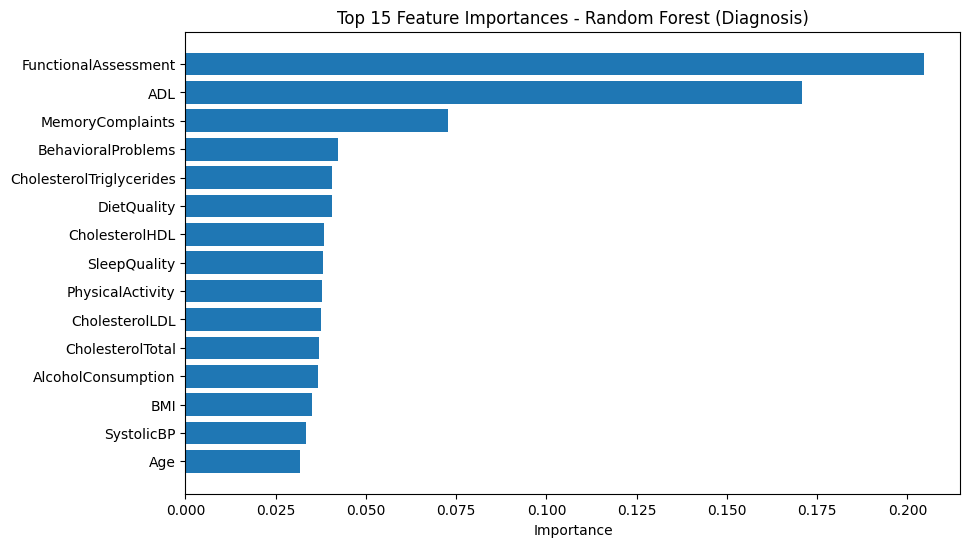

In [ ]:
# Feature importance for Random Forest (binary classification)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(10,6))
plt.title('Top 15 Feature Importances - Random Forest (Diagnosis)')
plt.barh(range(15), importances[indices][::-1], align='center')
plt.yticks(range(15), X.columns[indices][::-1])
plt.xlabel('Importance')
plt.show()

In [ ]:
# Summary table for regression models
print("=== Regression Model Comparison ===")
print(results_reg.T.round(4))

# Binary classification summary
print("\n=== Binary Classification Summary ===")
print(df_bin_results.round(4))

# Multiclass summary
print("\n=== Multiclass Classification Summary ===")
print(df_multi_results.round(4))

=== Regression Model Comparison ===
                  MSE     MAE   MAPE(%)      R2
Linear        73.6259  7.4124  402.6963 -0.0173
Ridge         73.6247  7.4124  402.6978 -0.0173
LASSO         72.9211  7.3979  401.6304 -0.0075
KernelRidge  112.1092  8.7422  348.3880 -0.5490

=== Binary Classification Summary ===
                     Model  Accuracy  Precision  Recall      F1     AUC
0      Logistic Regression    0.7930     0.7462  0.6340  0.6855  0.8648
1               Linear SVM    0.8070     0.7500  0.6863  0.7167  0.8659
2         Kernel SVM (RBF)    0.7930     0.7222  0.6797  0.7003  0.8616
3               KNN (k=15)    0.7023     0.6582  0.3399  0.4483  0.7778
4  Decision Tree (depth=4)    0.8628     0.7765  0.8627  0.8173  0.8869
5            Random Forest    0.8326     0.7755  0.7451  0.7600  0.8936

=== Multiclass Classification Summary ===
                     Model  Accuracy  F1 Macro  F1 Micro  F1 Weighted  \
0                SVM (OvR)    0.3698    0.1924    0.3698       0.

In [ ]:
# Error analysis for binary classification (example with Kernel SVM)
y_pred_svm = svm_rbf.predict(X_test_scaled)
errors = (y_pred_svm != y_bin_test)
error_indices = np.where(errors)[0]
print(f"Number of misclassifications (Kernel SVM): {len(error_indices)}")
# Show first 5 misclassified samples
print("First 5 misclassified test samples (features scaled):")
print(X_test_scaled[error_indices[:5]])
print("True labels:", y_bin_test.iloc[error_indices[:5]].values)
print("Predicted:", y_pred_svm[error_indices[:5]])
# Interpretation: These are likely borderline cases or feature outliers.

Number of misclassifications (Kernel SVM): 89
First 5 misclassified test samples (features scaled):
[[ 1.43886958 -1.0005819  -0.70190779  1.0120796   1.57696399  0.70271999
  -1.5403644   1.09807209 -1.465014   -0.57667854 -0.39891965 -0.42881732
  -0.51197123 -0.33236293 -0.42405371 -1.51761813 -1.09439241  0.12465506
  -0.78806265  0.02888297 -0.73967864  1.55749357 -0.509255    2.32170941
  -1.29324882 -0.50199892 -0.4345074  -0.41734917 -0.43922839  1.53967147]
 [ 0.44575107  0.99941844 -0.70190779  0.25067301  1.57696399  0.96130553
  -1.73725242  1.04819334  1.08781099 -0.57667854 -0.39891965 -0.42881732
  -0.51197123 -0.33236293 -0.42405371 -0.12647192 -0.41871294  1.53231081
  -1.70209772  1.38411852 -1.62124115 -0.59740702 -0.509255   -0.43071712
   0.00744376 -0.50199892 -0.4345074  -0.41734917 -0.43922839  1.53967147]
 [-0.32667443 -1.0005819  -0.70190779  0.10767342 -0.63412989 -0.89261733
   1.24638138  1.47644071 -1.33503866 -0.57667854 -0.39891965 -0.42881732
  -0.51197

**Error Analysis Interpretation**: Misclassifications often occur when the clinical features are ambiguous (e.g., patients with early‑stage Alzheimer’s may have MMSE scores close to normal). Improving feature engineering (e.g., adding interaction terms) and using more complex models (e.g., gradient boosting) could reduce these errors.